--- GAME VERSIONS COUNTS ---
- Patch 16.7: 6459 games
- Patch 16.6: 90 games
- Patch 16.8: 30 games
-------------------------

[Info] Selecting Patch '16.7' for analysis (6459 games).

[Success] Processed 6459 matches for Patch 16.7.

[Info] We successfully saw ALL 172 champions!

[Filter] 172 z 172 played minimum 5 games.

--- TOP 5 WINRATE CHAMPIONS (Patch 16.7) ---

 Champion  Games  Wins  Winrate (%)
TahmKench     34    22        64.71
   Rammus     60    36        60.00
    Brand    109    65        59.63
    Ziggs    200   118        59.00
  Hecarim    317   181        57.10

--- BOTTOM 5 WINRATE CHAMPIONS (Patch 16.7) ---

Champion  Games  Wins  Winrate (%)
    Sett     82    32        39.02
 Shyvana     90    35        38.89
   Yuumi     97    35        36.08
     Zac    133    45        33.83
   Amumu     41    13        31.71


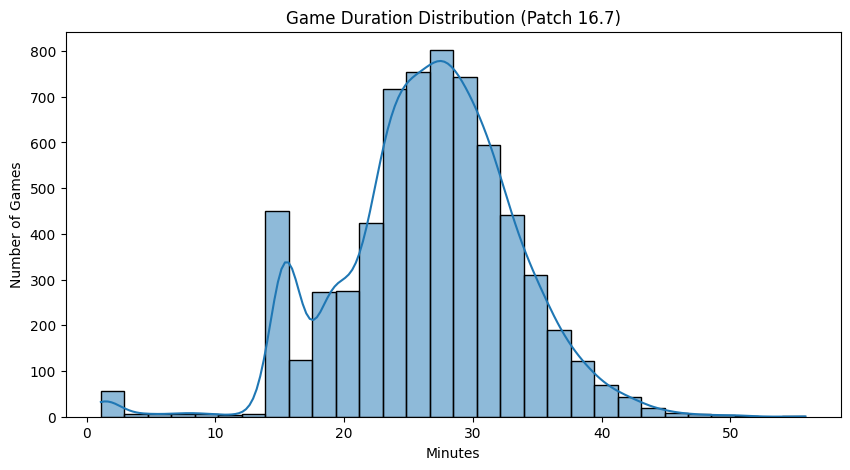

In [1]:
import pandas as pd
from pymongo import MongoClient
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict

# 1. Database Connection
client = MongoClient("mongodb://mongodb:27017/")
db = client["riot_data"]
matches_col = db["match_summaries"]

# ==========================================
# PASS 1: AGGREGATION (Find the most popular patch)
# ==========================================
pipeline = [
    {"$match": {"status": "downloaded"}},
    {"$group": {"_id": "$game_version", "count": {"$sum": 1}}},
    {"$sort": {"count": -1}}
]

version_counts = list(matches_col.aggregate(pipeline))

print("--- GAME VERSIONS COUNTS ---")
for vc in version_counts:
    v_name = vc["_id"] if vc["_id"] else "Unknown"
    print(f"- Patch {v_name}: {vc['count']} games")
print("-" * 25 + "\n")

if not version_counts:
    print("[Error] No downloaded matches found.")
else:
    # Get the top version
    top_version = version_counts[0]["_id"]
    top_count = version_counts[0]["count"]
    print(f"[Info] Selecting Patch '{top_version}' for analysis ({top_count} games).\n")

    # ==========================================
    # PASS 2: FETCH & ANALYZE ONLY THE TOP PATCH
    # ==========================================
    cursor = matches_col.find({
        "status": "downloaded", 
        "game_version": top_version
    })

    records = []
    unique_champions = set()
    champ_stats = defaultdict(lambda: {"wins": 0, "games": 0})

    total_number_of_champions = 172
    processed_matches = 0

    for doc in cursor:
        processed_matches += 1
        
        if "data" in doc and "info" in doc["data"]:
            info = doc["data"]["info"]
            
            # Extract Match Duration
            records.append({
                "match_id": doc["_id"],
                "game_duration": info.get("gameDuration")
            })
            
            # Extract Champion Data
            if "participants" in info:
                for participant in info["participants"]:
                    champ_id = participant.get("championId")
                    champ_name = participant.get("championName")
                    win = participant.get("win")
                    
                    if champ_id is not None and champ_name is not None:
                        unique_champions.add((champ_id, champ_name))
                        
                        champ_stats[champ_name]["games"] += 1
                        if win:
                            champ_stats[champ_name]["wins"] += 1

    print(f"[Success] Processed {processed_matches} matches for Patch {top_version}.\n")

    # --- RESULTS & VISUALIZATIONS ---

    if len(unique_champions) >= total_number_of_champions:
        print(f"[Info] We successfully saw ALL {len(unique_champions)} champions!\n")
    else:
        print(f"[Info] We saw {len(unique_champions)} out of {total_number_of_champions} champions.\n")

    # Winrate DataFrame
    stats_list = []
    for name, stats in champ_stats.items():
        winrate = (stats["wins"] / stats["games"]) * 100 if stats["games"] > 0 else 0
        stats_list.append({
            "Champion": name,
            "Games": stats["games"],
            "Wins": stats["wins"],
            "Winrate (%)": round(winrate, 2)
        })

    df_winrate = pd.DataFrame(stats_list)
    min_games_threshold = 5 
    
    # Filtrowanie
    df_final = df_winrate[df_winrate["Games"] >= min_games_threshold].sort_values(by="Winrate (%)", ascending=False)

    # NOWE: Informacja o progu kwalifikacji
    champs_above_threshold = len(df_final)
    total_champs_seen = len(df_winrate)
    print(f"[Filter] {champs_above_threshold} z {total_champs_seen} played minimum {min_games_threshold} games.\n")

    print(f"--- TOP 5 WINRATE CHAMPIONS (Patch {top_version}) ---\n")
    print(df_final.head(5).to_string(index=False))

    print(f"\n--- BOTTOM 5 WINRATE CHAMPIONS (Patch {top_version}) ---\n")
    print(df_final.tail(5).to_string(index=False))

    # Match Duration DataFrame & Plot
    df_matches = pd.DataFrame(records)

    plt.figure(figsize=(10, 5))
    sns.histplot(df_matches['game_duration'] / 60, bins=30, kde=True)
    plt.title(f"Game Duration Distribution (Patch {top_version})")
    plt.xlabel("Minutes")
    plt.ylabel("Number of Games")
    plt.show()